# icsR8 baseline reproduction (PBL / CLA / WCL)

Reproduces the published Table 1 values (`doc/icsR8_text.txt` §3.2) for both
scan directions using the `icsr8` library, and plots per-position error curves
and an estimate-vs-truth map.

In [1]:
from pathlib import Path

import pandas as pd

from icsr8.estimators import estimate_cla, estimate_pbl, estimate_wcl
from icsr8.evaluate import l2_errors, summary
from icsr8.fingerprint import candidate_medians, reproduction_fingerprint
from icsr8.io import load_ap_coords, load_location_coords, load_raw_scans
from icsr8.plotting import plot_error_by_position, plot_estimate_map

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = REPO / "data" / "dataset"
RAWDATA_ROOT = REPO / "data" / "rawdata"

METHODS = {"pbl": estimate_pbl, "cla": estimate_cla, "wcl": estimate_wcl}

# Published Table 1 (doc/icsR8_text.txt §3.2) - Std uses ddof=0
DOC_TABLE_1 = {
    "forward": {
        "pbl": {"Ave": 4.38, "Max": 13.6, "Std": 2.82},
        "cla": {"Ave": 8.07, "Max": 24.2, "Std": 5.33},
        "wcl": {"Ave": 3.57, "Max": 11.9, "Std": 2.42},
    },
    "backward": {
        "pbl": {"Ave": 4.52, "Max": 15.6, "Std": 3.14},
        "cla": {"Ave": 7.02, "Max": 18.0, "Std": 4.22},
        "wcl": {"Ave": 3.51, "Max": 12.2, "Std": 2.54},
    },
}

## Load data and build per-direction fingerprints

In [2]:
ap_coords = load_ap_coords(DATASET_DIR / "AP_coordinate_C3F.csv")
truth = load_location_coords(DATASET_DIR / "location_coordinate_C.csv")[["location_p", "x", "y"]]

fingerprints = {}
for direction in ("forward", "backward"):
    scans = load_raw_scans(direction, RAWDATA_ROOT)
    fingerprints[direction] = reproduction_fingerprint(candidate_medians(scans, ap_coords))

fingerprints["forward"].head()

,location_p,ap_name,ssid,frequency,rssi_median,x,y
0,1,AP-C0-3F-01,tutwifi,2412,-42.0,30.1,1.0
1,1,AP-C0-3F-02,tutwifi,2437,-53.5,20.8,-1.1
2,1,AP-C0-3F-03,tutwifi2025,6115,-65.0,9.1,1.0
3,2,AP-C0-3F-01,tutwifi,2412,-47.0,30.1,1.0
4,2,AP-C0-3F-02,tutwifi,2437,-44.0,20.8,-1.1


## Estimate PBL / CLA / WCL for both directions and compare to the published baseline

In [3]:
results = {}
rows = []
for direction, fp in fingerprints.items():
    for method_name, estimator in METHODS.items():
        est = estimator(fp)
        err = l2_errors(est, truth)
        stats = summary(err["error"])
        results[(direction, method_name)] = {"estimates": est, "errors": err, "stats": stats}

        expected = DOC_TABLE_1[direction][method_name]
        rows.append({
            "direction": direction,
            "method": method_name,
            "Ave": stats["Ave"], "Ave_doc": expected["Ave"],
            "Max": stats["Max"], "Max_doc": expected["Max"],
            "Std": stats["Std"], "Std_doc": expected["Std"],
        })

comparison = pd.DataFrame(rows)
comparison

,direction,method,Ave,Ave_doc,Max,Max_doc,Std,Std_doc
0,forward,pbl,4.376257,4.38,13.636715,13.6,2.815797,2.82
1,forward,cla,8.071233,8.07,24.168965,24.2,5.325725,5.33
2,forward,wcl,3.568543,3.57,11.850898,11.9,2.423180,2.42
3,backward,pbl,4.517737,4.52,15.632018,15.6,3.135968,3.14
4,backward,cla,7.023453,7.02,18.002500,18.0,4.219232,4.22
5,backward,wcl,3.512499,3.51,12.169324,12.2,2.536420,2.54


## Error-by-position curves (per method, forward vs. backward overlaid)

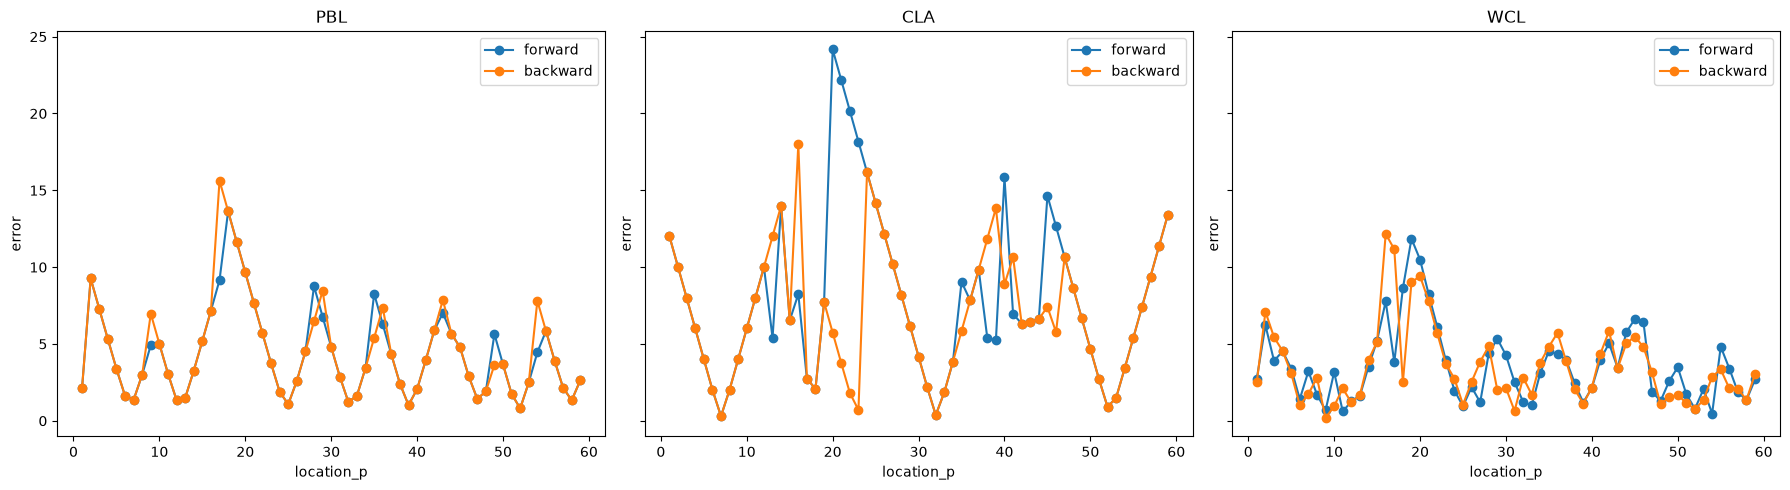

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, method_name in zip(axes, METHODS):
    plot_error_by_position(results[("forward", method_name)]["errors"], ax=ax, label="forward")
    plot_error_by_position(results[("backward", method_name)]["errors"], ax=ax, label="backward")
    ax.set_title(method_name.upper())
fig.tight_layout()

## Estimate-vs-truth map (WCL, forward)

<Axes: xlabel='x', ylabel='y'>

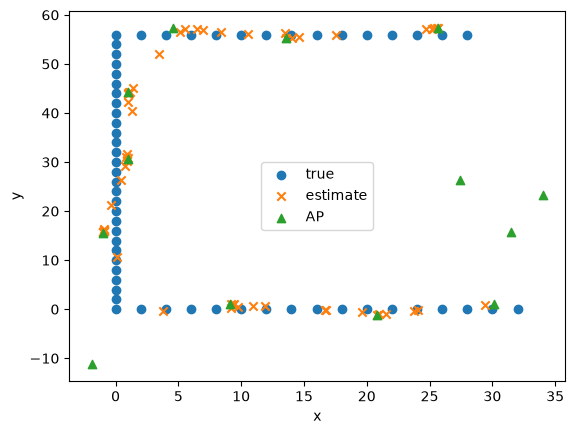

In [5]:
plot_estimate_map(
    results[("forward", "wcl")]["estimates"],
    truth,
    ap_coords=ap_coords,
)